# Training Baseline U-Net dan ProCANet

Notebook ini hanya orkestrasi eksekusi. Training, dataset loader, model, loss, metrik, checkpoint, early stopping, scheduler, gradient accumulation, AMP, dan opsi label water/river tetap memakai kode repo: `scripts/train_segmentation.py` dan modul `training/`.

Default target tetap flood-only dari `label_flood_binary`. Jika `COMMON_ARGS["water_river_as_flood"] = True`, command training menambahkan `--water-river`, sehingga target train/validation menjadi `label_flood_binary | label_water_river_mask` tanpa mengubah file tile.


## 1. Setup

In [1]:
from __future__ import annotations

import csv
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from scripts.train_segmentation import resolve_device
from training.datasets import FloodTileDataset

PROJECT_ROOT = Path.cwd()
TILE_ROOT = PROJECT_ROOT / "dataset" / "tiles"
RUNS_ROOT = PROJECT_ROOT / "runs"
DEVICE = resolve_device("auto")

print(f"Project root: {PROJECT_ROOT}")
print(f"Tile root: {TILE_ROOT}")
print(f"Device: {DEVICE}")
print(f"Torch: {torch.__version__}")

Project root: /home/nozomi/Productive/skripsi
Tile root: /home/nozomi/Productive/skripsi/dataset/tiles
Device: cuda
Torch: 2.12.0+cu130


## 2. Cek split dataset

In [2]:
def count_tiles(architecture: str) -> dict[str, int]:
    return {
        split: len(FloodTileDataset(split, architecture=architecture, root=TILE_ROOT, augment=False))
        for split in ("train", "val", "test")
    }

tile_counts = {
    "unet": count_tiles("unet"),
    "procanet": count_tiles("procanet"),
}
tile_counts

{'unet': {'train': 983, 'val': 36, 'test': 102},
 'procanet': {'train': 983, 'val': 36, 'test': 102}}

## 3. Konfigurasi eksperimen

Ubah nilai di `COMMON_ARGS` sebelum menjalankan training:

- `water_river_as_flood=False`: default, hanya `label_flood_binary` menjadi label flood.
- `water_river_as_flood=True`: eksperimen union label `label_flood_binary | label_water_river_mask` untuk train/validation.
- `lr_scheduler="reduce-on-plateau"`: turunkan LR saat validation IoU stagnan.
- `gradient_accumulation_steps`: naikkan effective batch size tanpa menambah VRAM sebesar batch asli.
- `amp=True`: aktifkan automatic mixed precision saat device CUDA; pada CPU otomatis tetap FP32.


In [4]:
COMMON_ARGS = {
    "epochs": 100,
    "batch_size": 4,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "lr_scheduler": "reduce-on-plateau",
    "lr_factor": 0.5,
    "lr_patience": 3,
    "gradient_accumulation_steps": 2,
    "amp": True,
    "water_river_as_flood": True,
    "num_workers": 4,
    "base_channels": 32,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 1e-4,
    "max_batches": None,
}

EXPERIMENTS = [
    {
        "name": "baseline_unet",
        "architecture": "unet",
        "output_dir": RUNS_ROOT / "baseline_unet",
    },
    {
        "name": "procanet",
        "architecture": "procanet",
        "output_dir": RUNS_ROOT / "procanet",
    },
]

COMMON_ARGS, EXPERIMENTS


({'epochs': 100,
  'batch_size': 4,
  'lr': 0.0001,
  'weight_decay': 0.0001,
  'lr_scheduler': 'reduce-on-plateau',
  'lr_factor': 0.5,
  'lr_patience': 3,
  'gradient_accumulation_steps': 2,
  'amp': True,
  'water_river_as_flood': True,
  'num_workers': 4,
  'base_channels': 32,
  'early_stopping_patience': 10,
  'early_stopping_min_delta': 0.0001,
  'max_batches': None},
 [{'name': 'baseline_unet',
   'architecture': 'unet',
   'output_dir': PosixPath('/home/nozomi/Productive/skripsi/runs/baseline_unet')},
  {'name': 'procanet',
   'architecture': 'procanet',
   'output_dir': PosixPath('/home/nozomi/Productive/skripsi/runs/procanet')}])

## 4. Fungsi eksekusi training

In [5]:
def build_train_command(experiment: dict, common_args: dict) -> list[str]:
    cmd = [
        "uv",
        "run",
        "python",
        "-m",
        "scripts.train_segmentation",
        "--architecture",
        experiment["architecture"],
        "--epochs",
        str(common_args["epochs"]),
        "--batch-size",
        str(common_args["batch_size"]),
        "--lr",
        str(common_args["lr"]),
        "--weight-decay",
        str(common_args["weight_decay"]),
        "--lr-scheduler",
        str(common_args["lr_scheduler"]),
        "--lr-factor",
        str(common_args["lr_factor"]),
        "--lr-patience",
        str(common_args["lr_patience"]),
        "--gradient-accumulation-steps",
        str(common_args["gradient_accumulation_steps"]),
        "--num-workers",
        str(common_args["num_workers"]),
        "--device",
        "auto",
        "--output-dir",
        str(experiment["output_dir"]),
        "--tile-root",
        str(TILE_ROOT),
        "--base-channels",
        str(common_args["base_channels"]),
        "--early-stopping-patience",
        str(common_args["early_stopping_patience"]),
        "--early-stopping-min-delta",
        str(common_args["early_stopping_min_delta"]),
    ]
    if common_args["amp"]:
        cmd.append("--amp")
    if common_args["water_river_as_flood"]:
        cmd.append("--water-river")
    if common_args["max_batches"] is not None:
        cmd.extend(["--max-batches", str(common_args["max_batches"])])
    return cmd


def run_training(experiment: dict, common_args: dict = COMMON_ARGS) -> None:
    experiment["output_dir"].mkdir(parents=True, exist_ok=True)
    cmd = build_train_command(experiment, common_args)
    print(" ".join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)


def run_all_experiments() -> None:
    for experiment in EXPERIMENTS:
        print(f"\n=== Training {experiment['name']} ===")
        run_training(experiment)


## 5. Jalankan training

Cell ini menjalankan eksperimen di `EXPERIMENTS`:

- baseline U-Net dan/atau ProCANet pada split `train`, validasi split `val`
- checkpoint terbaik `best.pt` berdasarkan validation IoU
- log training `metrics.csv`, termasuk kolom `lr`
- konfigurasi eksperimen `config.json`, termasuk `water_river_as_flood`, scheduler, gradient accumulation, `amp`, dan `amp_effective`

Untuk eksperimen water/river-as-flood, set `COMMON_ARGS["water_river_as_flood"] = True` sebelum menjalankan cell ini.


In [6]:
run_all_experiments()


=== Training baseline_unet ===
uv run python -m scripts.train_segmentation --architecture unet --epochs 100 --batch-size 4 --lr 0.0001 --weight-decay 0.0001 --lr-scheduler reduce-on-plateau --lr-factor 0.5 --lr-patience 3 --gradient-accumulation-steps 2 --num-workers 4 --device auto --output-dir /home/nozomi/Productive/skripsi/runs/baseline_unet --tile-root /home/nozomi/Productive/skripsi/dataset/tiles --base-channels 32 --early-stopping-patience 10 --early-stopping-min-delta 0.0001 --amp --water-river


unet epoch 2/100 train:   0%|                          | 0/246 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.1905450731273588, 'train_iou': 0.2757226642640627, 'train_dice': 0.43226113635461866, 'val_loss': 1.0193831192122564, 'val_iou': 0.516428842127876, 'val_dice': 0.6811118699156569, 'lr': 0.0001, 'best_val_iou': 0.516428842127876, 'saved': 1, 'bad_epochs': 0, 'stopped_early': 0}


unet epoch 3/100 train:   0%|                          | 0/246 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 1.0006482320103218, 'train_iou': 0.5829258467705388, 'train_dice': 0.736516935344527, 'val_loss': 0.949881460931566, 'val_iou': 0.5759591427704585, 'val_dice': 0.7309315668653068, 'lr': 0.0001, 'best_val_iou': 0.5759591427704585, 'saved': 1, 'bad_epochs': 0, 'stopped_early': 0}


...

{'epoch': 29, 'train_loss': 0.48391860511487095, 'train_iou': 0.7006157128726425, 'train_dice': 0.8239553563681684, 'val_loss': 0.6363146801789602, 'val_iou': 0.6491378887577924, 'val_dice': 0.7872451335730979, 'lr': 1.25e-05, 'best_val_iou': 0.6587583443851929, 'saved': 0, 'bad_epochs': 8, 'stopped_early': 0}


procanet epoch 31/100 train:   0%|                     | 0/246 [00:00<?, ?it/s]

{'epoch': 30, 'train_loss': 0.4972000619987162, 'train_iou': 0.7027711355385777, 'train_dice': 0.8254440316388084, 'val_loss': 0.6327200101481544, 'val_iou': 0.6544022412032203, 'val_dice': 0.7911041521888703, 'lr': 1.25e-05, 'best_val_iou': 0.6587583443851929, 'saved': 0, 'bad_epochs': 9, 'stopped_early': 0}


procanet epoch 31/100 val: 100%|█████████████████| 9/9 [00:03<00:00,  2.91it/s]


{'epoch': 31, 'train_loss': 0.48069520019055384, 'train_iou': 0.7053429046101318, 'train_dice': 0.8272153391594687, 'val_loss': 0.6305340147680707, 'val_iou': 0.6544185139290468, 'val_dice': 0.7911160427900202, 'lr': 1.25e-05, 'best_val_iou': 0.6587583443851929, 'saved': 0, 'bad_epochs': 10, 'stopped_early': 1}


## 6. Baca log training

In [7]:
def read_metrics(path: Path) -> list[dict[str, float | int | bool | None]]:
    rows = []
    with path.open(newline="") as f:
        for row in csv.DictReader(f):
            lr_value = row.get("lr")
            parsed = {
                "epoch": int(row["epoch"]),
                "train_loss": float(row["train_loss"]),
                "train_iou": float(row["train_iou"]),
                "train_dice": float(row["train_dice"]),
                "val_loss": float(row["val_loss"]),
                "val_iou": float(row["val_iou"]),
                "val_dice": float(row["val_dice"]),
                "lr": float(lr_value) if lr_value not in (None, "") else None,
                "best_val_iou": float(row["best_val_iou"]),
                "saved": bool(int(row["saved"])),
                "bad_epochs": int(row["bad_epochs"]),
                "stopped_early": bool(int(row["stopped_early"])),
            }
            rows.append(parsed)
    return rows


metrics = {
    experiment["name"]: read_metrics(experiment["output_dir"] / "metrics.csv")
    for experiment in EXPERIMENTS
}

summary = {
    name: {
        "epochs_ran": len(rows),
        "best_val_iou": max(row["val_iou"] for row in rows),
        "best_val_dice": max(row["val_dice"] for row in rows),
        "final_lr": rows[-1]["lr"],
    }
    for name, rows in metrics.items()
}
summary


{'baseline_unet': {'epochs_ran': 38,
  'best_val_iou': 0.648043638837077,
  'best_val_dice': 0.7864399019122595,
  'final_lr': 6.25e-06},
 'procanet': {'epochs_ran': 31,
  'best_val_iou': 0.6587583443851929,
  'best_val_dice': 0.7942788611916307,
  'final_lr': 1.25e-05}}

## 7. Plot dan simpan grafik

PosixPath('/home/nozomi/Productive/skripsi/runs/training_curves.png')

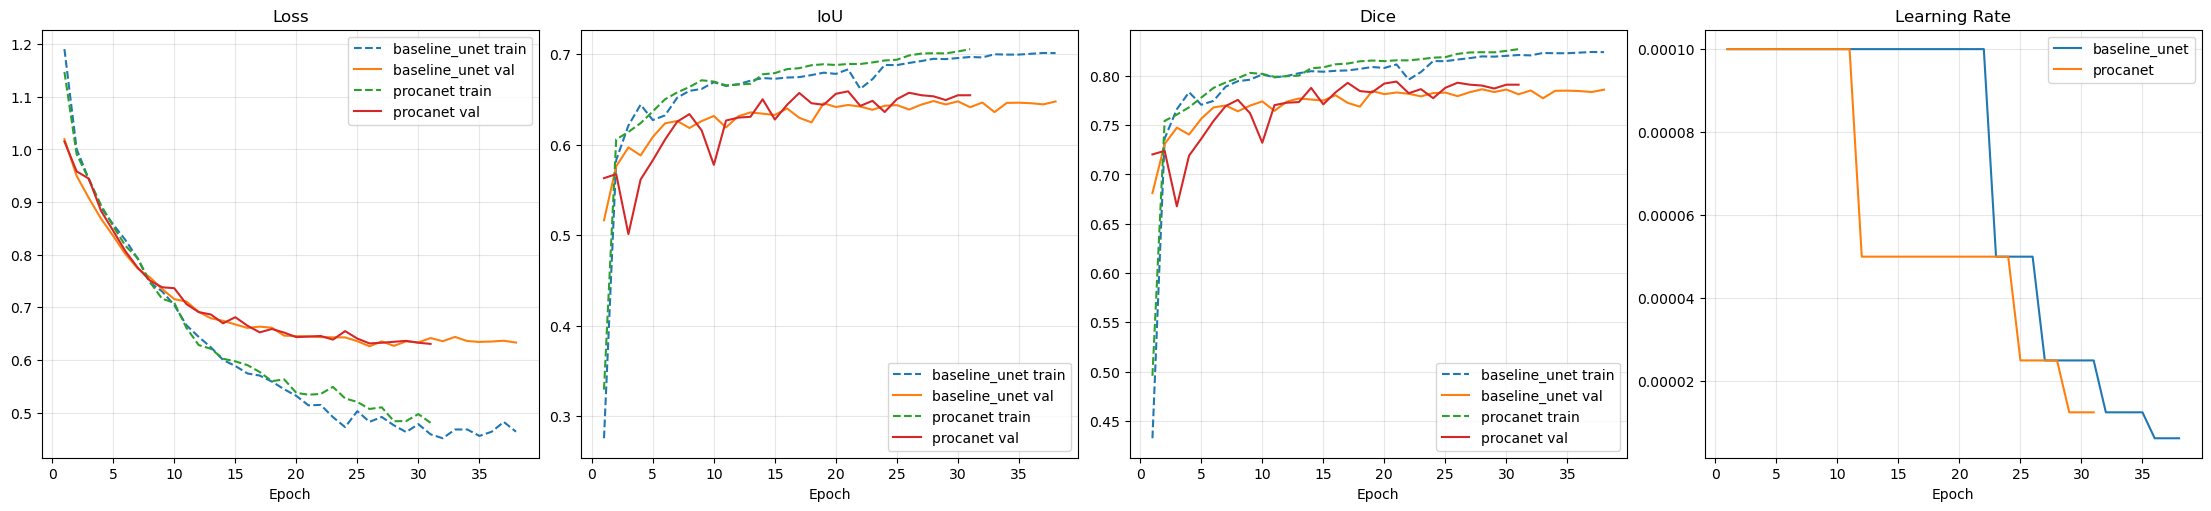

In [8]:
def plot_training_curves(metrics: dict[str, list[dict]]) -> Path:
    fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)
    specs = [
        ("loss", "Loss", "train_loss", "val_loss"),
        ("iou", "IoU", "train_iou", "val_iou"),
        ("dice", "Dice", "train_dice", "val_dice"),
    ]
    for ax, (_, title, train_key, val_key) in zip(axes[:3], specs):
        for name, rows in metrics.items():
            epochs = [row["epoch"] for row in rows]
            ax.plot(epochs, [row[train_key] for row in rows], linestyle="--", label=f"{name} train")
            ax.plot(epochs, [row[val_key] for row in rows], label=f"{name} val")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
        ax.legend()

    lr_ax = axes[3]
    for name, rows in metrics.items():
        lr_rows = [row for row in rows if row.get("lr") is not None]
        if lr_rows:
            lr_ax.plot([row["epoch"] for row in lr_rows], [row["lr"] for row in lr_rows], label=name)
    lr_ax.set_title("Learning Rate")
    lr_ax.set_xlabel("Epoch")
    lr_ax.grid(True, alpha=0.3)
    lr_ax.legend()

    RUNS_ROOT.mkdir(parents=True, exist_ok=True)
    output_path = RUNS_ROOT / "training_curves.png"
    fig.savefig(output_path, dpi=160)
    return output_path


plot_path = plot_training_curves(metrics)
plot_path


## 8. Cek output wajib

In [9]:
required_outputs = []
for experiment in EXPERIMENTS:
    output_dir = experiment["output_dir"]
    required_outputs.extend([
        output_dir / "best.pt",
        output_dir / "metrics.csv",
        output_dir / "config.json",
    ])
required_outputs.append(RUNS_ROOT / "training_curves.png")

missing = [path for path in required_outputs if not path.exists()]
if missing:
    raise FileNotFoundError("Missing outputs: " + ", ".join(str(path) for path in missing))

for path in required_outputs:
    print(path)

/home/nozomi/Productive/skripsi/runs/baseline_unet/best.pt
/home/nozomi/Productive/skripsi/runs/baseline_unet/metrics.csv
/home/nozomi/Productive/skripsi/runs/baseline_unet/config.json
/home/nozomi/Productive/skripsi/runs/procanet/best.pt
/home/nozomi/Productive/skripsi/runs/procanet/metrics.csv
/home/nozomi/Productive/skripsi/runs/procanet/config.json
/home/nozomi/Productive/skripsi/runs/training_curves.png
